In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import apriori, association_rules
from pathlib import Path

In [77]:
DATA_DIR = Path("git-forked-database")

main_df = pd.read_csv(DATA_DIR / "books.csv")
book_tags_df = pd.read_csv(DATA_DIR / "book_tags.csv")
ratings_df = pd.read_csv(DATA_DIR / "ratings.csv")
tags_df = pd.read_csv(DATA_DIR / "tags.csv")
to_read_df = pd.read_csv(DATA_DIR / "to_read.csv")


In [78]:
# Quick print to make sure all df are csv are correctly read
print(main_df.head())
print(book_tags_df.head())
print(ratings_df.head())
print(tags_df.head())
print(to_read_df.head())

   book_id  goodreads_book_id  best_book_id  work_id  books_count       isbn  \
0        1            2767052       2767052  2792775          272  439023483   
1        2                  3             3  4640799          491  439554934   
2        3              41865         41865  3212258          226  316015849   
3        4               2657          2657  3275794          487   61120081   
4        5               4671          4671   245494         1356  743273567   

         isbn13                      authors  original_publication_year  \
0  9.780439e+12              Suzanne Collins                     2008.0   
1  9.780440e+12  J.K. Rowling, Mary GrandPré                     1997.0   
2  9.780316e+12              Stephenie Meyer                     2005.0   
3  9.780061e+12                   Harper Lee                     1960.0   
4  9.780743e+12          F. Scott Fitzgerald                     1925.0   

                             original_title  ... ratings_count  \
0 

Data Cleaning:
<ul>
  <li>Dropping unnecessary columns in main_df</li>
  <li>Changing publication year from float to int</li>
  <li>standardizing all english (eng, en-US, en-CA, en-GB) to eng</li>
  <li>merge ratings_df onto main_df</li>
</ul>

In [79]:
main_df.head()
main_df.drop(columns=['image_url', 'small_image_url', 'books_count', 'work_id', 'best_book_id', 'isbn', 'isbn13'], inplace=True)
main_df['original_publication_year'] = main_df['original_publication_year'].astype('Int64')

# main_df['language_code'].value_counts()

main_df['language_code'] = main_df['language_code'].str.split('-').str[0]
main_df['language_code'] = main_df['language_code'].replace({
    'en': 'eng'
})
main_df.tail()
# Note: scrolling through the csv, some strings in original_title is missing

,book_id,goodreads_book_id,authors,original_publication_year,original_title,title,language_code,average_rating,ratings_count,work_ratings_count,work_text_reviews_count,ratings_1,ratings_2,ratings_3,ratings_4,ratings_5
9995,9996,7130616,Ilona Andrews,2010,Bayou Moon,"Bayou Moon (The Edge, #2)",eng,4.09,17204,18856,1180,105,575,3538,7860,6778
9996,9997,208324,Robert A. Caro,1990,Means of Ascent,"Means of Ascent (The Years of Lyndon Johnson, #2)",eng,4.25,12582,12952,395,303,551,1737,3389,6972
9997,9998,77431,Patrick O'Brian,1977,The Mauritius Command,The Mauritius Command,eng,4.35,9421,10733,374,11,111,1191,4240,5180
9998,9999,8565083,Peggy Orenstein,2011,Cinderella Ate My Daughter: Dispatches from the Frontlines of the New Girlie-Girl Culture,Cinderella Ate My Daughter: Dispatches from the Frontlines of the New Girlie-Girl Culture,eng,3.65,11279,11994,1988,275,1002,3765,4577,2375
9999,10000,8914,John Keegan,1998,The First World War,The First World War,NaN,4.00,9162,9700,364,117,345,2031,4138,3069


In [80]:
df = ratings_df.merge(main_df, on='book_id', how='left')
#df.head() #to confirm the merge happened
# df.shape #to confirm the merge happened

# will undergo further cleaning, this is a proof of concept


EDA lowkey need to redo

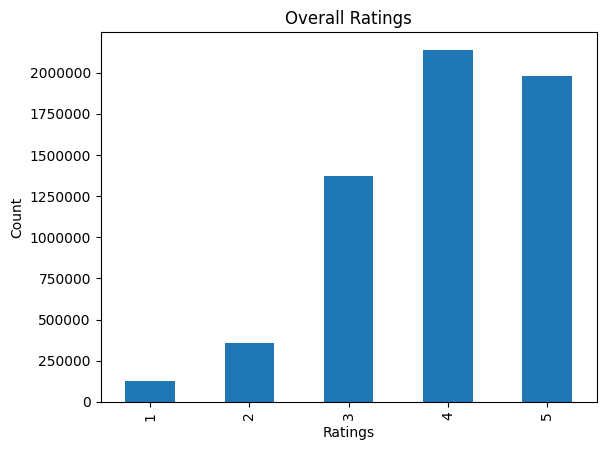

In [81]:
df['rating'].value_counts().sort_index().plot.bar(title ="Overall Ratings", xlabel = "Ratings", ylabel = "Count")
plt.ticklabel_format(style='plain', axis='y')

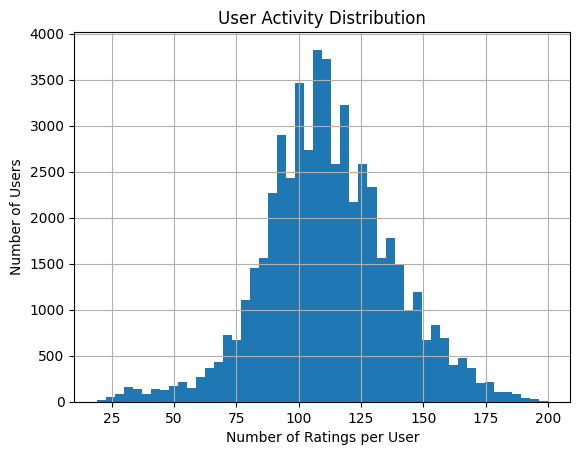

In [82]:
df['user_id'].value_counts().hist(bins=50)
plt.xlabel("Number of Ratings per User")
plt.ylabel("Number of Users")
plt.title("User Activity Distribution")

plt.show()

In [83]:
df['book_id'].value_counts()
# .hist(bins=50)


book_id
1       22806
2       21850
4       19088
3       16931
5       16604
        ...  
9315       36
1935       33
9486       24
9345       11
7803        8
Name: count, Length: 10000, dtype: int64

<Axes: >

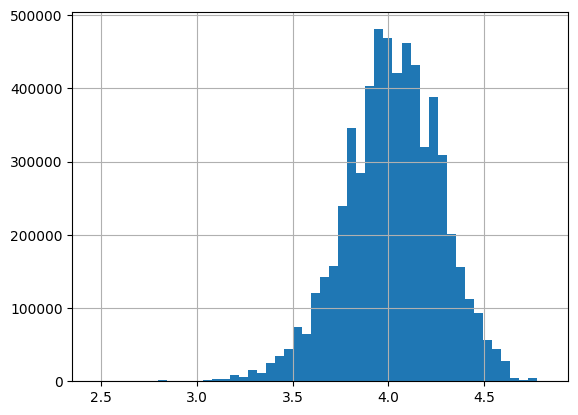

In [84]:
df['average_rating'].hist(bins=50)


<Axes: >

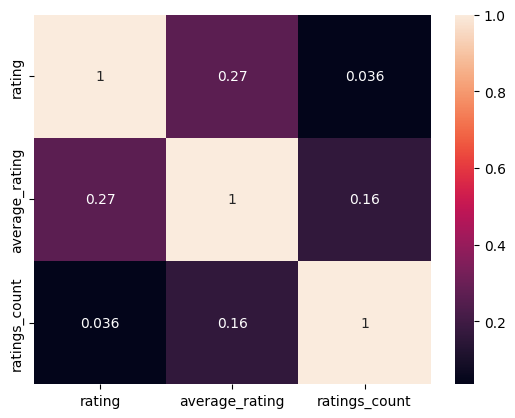

In [85]:
sns.heatmap(df[['rating', 'average_rating', 'ratings_count']].corr(), annot=True)

Prepping data for Apriori and KNN
<ul>
  <li>ratings_df set to only contain "popular books" which are books with at least 50 ratings</li>
  <li>determine active user threshold using iqr</li>
  <li>filter books df for popular books and active user</li>
  
  <li>merge book_tags_df with tags_df to get readable names</li>
  <li>map goodread ids to our main df book_id</li>
  <li>create a df of genre's cleaned and standardized </li>
  <li>use this for apriori</li>
</ul>


In [91]:
user_counts = ratings_df['user_id'].value_counts()
print(len(user_counts))
print(len(user_counts[user_counts >= 48]))

53424
52616


In [70]:
book_counts = ratings_df['book_id'].value_counts()
popular_books = book_counts[book_counts >= 50].index
ratings_df = ratings_df[ratings_df['book_id'].isin(popular_books)]

user_counts = ratings_df['user_id'].value_counts()
Q1 = user_counts.quantile(0.25)
Q3 = user_counts.quantile(0.75)
IQR = Q3 - Q1
threshold =  (Q1 - 1.5 * IQR)
print(threshold)


user_counts = ratings_df['user_id'].value_counts()
active_users = user_counts[user_counts >= threshold].index
ratings_df = ratings_df[ratings_df['user_id'].isin(active_users)]

df = ratings_df.merge(main_df, on='book_id', how='left')

48.0


In [71]:
book_tags_named = book_tags_df.merge(tags_df, on='tag_id', how='left')

book_tags_named = book_tags_named.merge(
    main_df[['book_id', 'goodreads_book_id']],
    on='goodreads_book_id',
    how='left'
)

# book_tags_named.head()

In [ ]:
# only keep tag if it's appeared at least 500 times
book_tags_named = book_tags_named[book_tags_named['count'] >= 500]

# book_tags_named['tag_name'].value_counts().head(30)


genre_tags = book_tags_named.copy()
genre_tags['tag_name'] = genre_tags['tag_name'].str.lower()
genre_tags['tag_name'] = genre_tags['tag_name'].replace({
    'sci-fi': 'science-fiction',
    'ya': 'young-adult',
    'urban-fantasy': 'fantasy',
    'vampires': 'paranormal',
    'classic': 'classics'
})
valid_genres = [
    'fantasy', 'romance', 'mystery', 'science-fiction',
    'young-adult', 'historical-fiction', 'non-fiction',
    'paranormal', 'horror', 'graphic-novels', 'manga'
]

genre_tags = genre_tags[
    genre_tags['tag_name'].isin(valid_genres)
]

Apriori

In [99]:
# lets recommend books if a user likes a previous book (defined as 4 or higher rating)
top_books = df['book_id'].value_counts().head(500).index

liked_books = df[
    (df['rating'] >= 4) &
    (df['book_id'].isin(top_books))
]

user_genres = liked_books.merge(
    genre_tags[['book_id', 'tag_name']],
    on='book_id',
    how='inner'
)


In [100]:
genre_data = pd.crosstab(
    user_genres['user_id'],
    user_genres['tag_name']
)
genre_data.head()
genre_data = genre_data.astype(bool)


In [101]:
# run for apriori and association
frequent_itemsets = apriori(genre_data, min_support = 0.1, use_colnames=True)
rules = association_rules(frequent_itemsets, num_itemsets=10, metric="confidence", min_threshold=0.5)

rules = rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']]
rules = rules[(rules['support'] >= 0.1) &
              (rules['confidence'] >= 0.5) &
              (rules['lift'] >= 1.0)]

rules = rules[rules['consequents'].apply(lambda x: len(x) == 1)]
rules = rules[rules['antecedents'].apply(lambda x: len(x) == 2)]
rules = rules.sort_values('confidence', ascending=[False])
rules

,antecedents,consequents,support,confidence,lift
156,"(paranormal, mystery)",(fantasy),0.644231,0.999883,1.028168
127,"(paranormal, horror)",(fantasy),0.475877,0.999842,1.028126
203,"(paranormal, romance)",(fantasy),0.643892,0.999795,1.028078
180,"(paranormal, non-fiction)",(fantasy),0.429738,0.999737,1.028018
209,"(paranormal, science-fiction)",(fantasy),0.653865,0.999712,1.027993
...,...,...,...,...,...
142,"(fantasy, young-adult)",(horror),0.606654,0.640165,1.030781
195,"(fantasy, young-adult)",(non-fiction),0.605543,0.638994,1.016971
444,"(paranormal, mystery)",(non-fiction),0.411072,0.638007,1.015400
131,"(fantasy, romance)",(horror),0.551426,0.636622,1.025077


Lift is too close to 1, will change genre to be more specific maybe

In [102]:
rules['lift'].describe()

count    247.000000
mean       1.049292
std        0.032106
min        1.000602
25%        1.025543
50%        1.038729
75%        1.070949
max        1.188886
Name: lift, dtype: float64

In [97]:
book_tags_named['tag_name'].value_counts().head(50)

tag_name
to-read               9043
currently-reading     2992
favorites             1757
fiction               1704
fantasy               1339
young-adult            923
romance                717
classics               504
books-i-own            482
ya                     481
non-fiction            479
mystery                464
historical-fiction     451
owned                  381
science-fiction        370
paranormal             359
sci-fi                 285
series                 246
urban-fantasy          228
horror                 215
graphic-novels         185
vampires               183
nonfiction             177
contemporary           171
book-club              162
childrens              159
classic                152
comics                 147
favourites             140
history                140
paranormal-romance     139
dystopian              128
dystopia               108
humor                  107
historical             103
chick-lit               97
literature         

In [98]:
genre_tags['tag_name'] = genre_tags['tag_name'].replace({
    'sci-fi': 'science-fiction',
    'ya': 'young-adult',
    'urban-fantasy': 'fantasy',
    'vampires': 'paranormal',
    'classic': 'classics',
    'dystopian': 'dystopia',
})
valid_genres = [
    'fantasy', 'romance', 'mystery', 'science-fiction',
    'young-adult', 'historical-fiction', 'non-fiction',
    'paranormal', 'horror', 'graphic-novels', 'manga', 'dystopia',
    'contemporary', 'thriller', 'humor', 'contemporary',
    'book-club', #this could be good; book-club books tend to be similar to one another (anecdote)
]

genre_tags = genre_tags[
    genre_tags['tag_name'].isin(valid_genres)
]

In [103]:
top_books = df['book_id'].value_counts().head(500).index

liked_books = df[
    (df['rating'] >= 4) &
    (df['book_id'].isin(top_books))
]

user_genres = liked_books.merge(
    genre_tags[['book_id', 'tag_name']],
    on='book_id',
    how='inner'
)
genre_data = pd.crosstab(
    user_genres['user_id'],
    user_genres['tag_name']
)
genre_data.head()
genre_data = genre_data.astype(bool)
frequent_itemsets = apriori(genre_data, min_support = 0.1, use_colnames=True)
rules = association_rules(frequent_itemsets, num_itemsets=10, metric="confidence", min_threshold=0.5)

rules = rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']]
rules = rules[(rules['support'] >= 0.1) &
              (rules['confidence'] >= 0.5) &
              (rules['lift'] >= 1.0)]

rules = rules[rules['consequents'].apply(lambda x: len(x) == 1)]
rules = rules[rules['antecedents'].apply(lambda x: len(x) == 2)]
rules = rules.sort_values('confidence', ascending=[False])
rules
# rerun

,antecedents,consequents,support,confidence,lift
156,"(paranormal, mystery)",(fantasy),0.644231,0.999883,1.028168
127,"(paranormal, horror)",(fantasy),0.475877,0.999842,1.028126
203,"(paranormal, romance)",(fantasy),0.643892,0.999795,1.028078
180,"(paranormal, non-fiction)",(fantasy),0.429738,0.999737,1.028018
209,"(paranormal, science-fiction)",(fantasy),0.653865,0.999712,1.027993
...,...,...,...,...,...
142,"(fantasy, young-adult)",(horror),0.606654,0.640165,1.030781
195,"(fantasy, young-adult)",(non-fiction),0.605543,0.638994,1.016971
444,"(paranormal, mystery)",(non-fiction),0.411072,0.638007,1.015400
131,"(fantasy, romance)",(horror),0.551426,0.636622,1.025077
